# Imports

Enable operations to use the cpu if no Apple gpu implementation is available

In [1]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1

env: PYTORCH_ENABLE_MPS_FALLBACK=1


Reload modules automagically if they change

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import json
import sklearn
import ot
import torch
from ot_utils import *
from sklearn.svm import SVC
from Utils.SVM_utils import test_svm, train_svm
from einops import rearrange
from Utils.visualization_utils import visualize_barycenter_diracs, plot_images, plot_pca_for_arrays
from Utils.joint_OT_mapping_linear_classreg import free_support_sinkhorn_barycenter, compute_joint_OT_mapping, MappingTransport
from warnings import catch_warnings
from map_hyperparam import optimize_hyperparams
from sklearn.cluster import MiniBatchKMeans

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
device

device(type='mps')

# Data

In [5]:
data_path = '/Users/balazsmorvay/PycharmProjects/fmri_classifier/Data/Office-Caltech'

Read the image features

In [6]:
dataset = np.load(os.path.join(data_path, 'Objects_Decaf.npy'))
with open(os.path.join(data_path, 'Objects_crossval_index.json'), 'r') as f:
    fold_dict = json.loads(f.read())

domain_names = ['Webcam', 'Amazon', 'dslr', 'Caltech']

Set the number of classes within each domain

In [7]:
n_classes = 10
standardize = False

In [8]:
dataset.shape

(2533, 4098)

In [9]:
X = dataset[:, :-2]
#if standardize:
#    X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
#else:
#    # Feature scaling
#    X = (X - np.min(X, axis=0)) / (np.max(X, axis=0) - np.min(X, axis=0))

y = np.array(dataset[:, -2], dtype=int)
m = np.array(dataset[:, -1], dtype=int)
domains = np.unique(m).astype(int)
targets = domains
n_domains = len(domains)

Dataset has shape n_points x n_features

In [10]:
X.shape, y.shape, targets.shape

((2533, 4096), (2533,), (4,))

### Number of samples coming from a given domain, having a given class

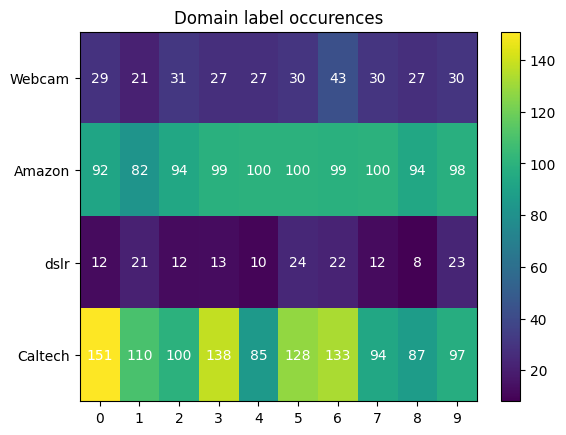

In [11]:
label_domain_occurence = np.zeros((4, 10), dtype=int)
for label in range(10):
    for i, domain in enumerate(domains):
        domain_indices = np.where(m == domain)
        domain_labels = y[domain_indices]
        label_indices = np.where(domain_labels == label+1)
        label_domain_occurence[i][label] = len(label_indices[0])

fig, ax = plt.subplots()
cax = ax.imshow(label_domain_occurence, cmap='viridis', aspect='auto')
for (i, j), val in np.ndenumerate(label_domain_occurence):
    ax.text(j, i, f'{val}', ha='center', va='center', color='white')
fig.colorbar(cax)
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(4))
ax.set_xticklabels(str(i) for i in range(10))
ax.set_yticklabels(domain_names)
plt.title('Domain label occurences')
plt.show()

# Training

In [12]:
n_training_data = 6

X_all = []
y_all = []
for i, domain in enumerate(domains):
    domain_indices = np.where(m == domain)
    # for c in range(10):
    #     class_indices = np.where(y == c+1)
    #     indices = np.intersect1d(class_indices, domain_indices)
    #     train_samples = torch.zeros(size=(n_training_data, 4096))
    #     test_samples = torch.zeros(size=(n_training_data, 4096))
    # 
    #     for j, idx in enumerate(indices):
    #         if j < n_training_data:
    #             train_samples[j, ...] = X[idx]
    #         else:
    X_all.append(torch.tensor(X[domain_indices], dtype=torch.float32, device=device))
    y_all.append(torch.tensor(y[domain_indices], dtype=torch.int, device=device))

In [13]:
X_trains = []
X_tests = []
y_trains = []
y_tests = []

for i in range(len(X_all)):
    X_i = X_all[i].cpu()
    y_i = y_all[i].cpu()
    X_i_train, X_i_test, y_i_train, y_i_test = sklearn.model_selection.train_test_split(X_i, y_i, train_size=0.3, shuffle=True, stratify=y_i, random_state=42)
    X_trains.append(X_i_train.to(device))
    X_tests.append(X_i_test.to(device))
    y_trains.append(y_i_train.to(device))
    y_tests.append(y_i_test.to(device))
    


In [14]:
X_trains[0].mean()

tensor(1.4348, device='mps:0')

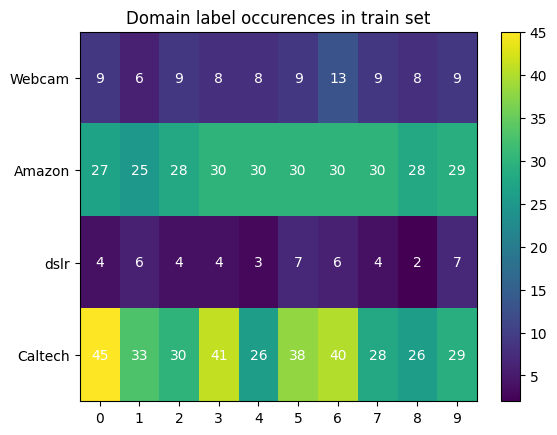

In [15]:
label_domain_occurence = np.zeros((4, 10), dtype=int)
for label in range(10):
    for i in range(n_domains):
        domain_labels = y_trains[i]
        label_indices = np.where(domain_labels.cpu() == label+1)
        label_domain_occurence[i][label] = len(label_indices[0])

fig, ax = plt.subplots()
cax = ax.imshow(label_domain_occurence, cmap='viridis', aspect='auto')
for (i, j), val in np.ndenumerate(label_domain_occurence):
    ax.text(j, i, f'{val}', ha='center', va='center', color='white')
fig.colorbar(cax)
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(4))
ax.set_xticklabels(str(i) for i in range(10))
ax.set_yticklabels(domain_names)
plt.title('Domain label occurences in train set')
plt.show()

Concatenate the train samples into one tensor

In [16]:
Xs = torch.concatenate(tensors=X_trains, dim=0)
ys = torch.concatenate(y_trains, dim=0)
Xs.shape, ys.shape

(torch.Size([758, 4096]), torch.Size([758]))

In [17]:
n_features = 4096

In [18]:
model = train_svm(X_trains[0].cpu(), y_trains[0].cpu(), kernel='rbf', C=1.0)
model.fit_status_ == 0

[LibSVM].*.*
optimization finished, #iter = 31
obj = -3.714448, rho = 0.214794
nSV = 15, nBSV = 0
.*.*
optimization finished, #iter = 42
obj = -4.692344, rho = 0.279217
nSV = 18, nBSV = 0
.*
optimization finished, #iter = 31
obj = -5.626428, rho = 0.387746
nSV = 17, nBSV = 2
.*.*
optimization finished, #iter = 34
obj = -3.610927, rho = 0.389529
nSV = 17, nBSV = 0
.*.*
optimization finished, #iter = 39
obj = -4.749156, rho = 0.406507
nSV = 18, nBSV = 0
.*
optimization finished, #iter = 39
obj = -6.314869, rho = 0.346856
nSV = 22, nBSV = 4
.*
optimization finished, #iter = 31
obj = -5.859736, rho = 0.304120
nSV = 18, nBSV = 3
.*
optimization finished, #iter = 30
obj = -3.838141, rho = 0.243667
nSV = 17, nBSV = 0
.*
optimization finished, #iter = 29
obj = -6.260178, rho = 0.361745
nSV = 18, nBSV = 4
.*
optimization finished, #iter = 29
obj = -3.908842, rho = 0.022335
nSV = 15, nBSV = 0
.*.*
optimization finished, #iter = 28
obj = -4.357911, rho = 0.075192
nSV = 14, nBSV = 0
.*
optimizatio

True

{'accuracy': 0.6676602086438153, 'recall': array([0.56923077, 0.9122807 , 0.72727273, 0.62318841, 0.71428571,
       0.48571429, 0.91304348, 0.78571429, 0.03030303, 0.92753623]), 'precision': array([0.94871795, 1.        , 0.75      , 0.78181818, 0.75757576,
       0.80952381, 0.35      , 0.96491228, 1.        , 0.56140351]), 'fscore': array([0.71153846, 0.95412844, 0.73846154, 0.69354839, 0.73529412,
       0.60714286, 0.5060241 , 0.86614173, 0.05882353, 0.69945355])}


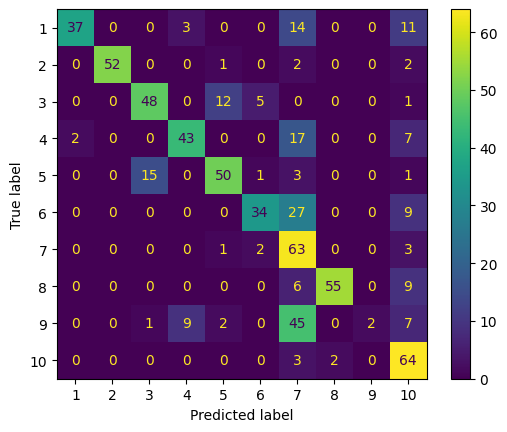

In [19]:
metrics, disp = test_svm(model, X_tests[1].cpu(), y_tests[1].cpu())
disp.plot()
print(metrics)

In [20]:
xs = X_trains[1]
xt = X_trains[0]
ys = y_trains[1]
yt = y_trains[0]
M = dist_classreg(xs, xt, ys, yt, device=device)

a = torch.tensor([1.0 / xs.shape[0]] * xs.shape[0], dtype=torch.float32, device=device)
b = torch.tensor([1.0 / xt.shape[0]] * xt.shape[0], dtype=torch.float32, device=device)

P = ot.sinkhorn(a=a, b=b, reg=2e-1, M=M, method='sinkhorn_log')

/Users/balazsmorvay/anaconda3/envs/fmri_classifier/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:748: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn("Sinkhorn did not converge. You might want to "


In [21]:
M.min()

tensor(68891.0938, device='mps:0')

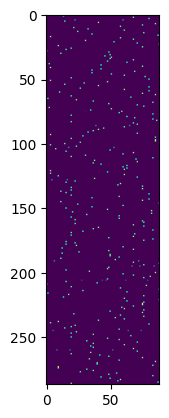

In [22]:
plt.imshow(P.cpu())

In [23]:
transp_xs = barycentric_mapping(xs, xt, X_tests[1], P)

{'accuracy': 0.8852459016393442, 'recall': array([0.89230769, 0.9122807 , 0.77272727, 0.79710145, 0.94285714,
       0.94285714, 0.86956522, 0.88571429, 0.87878788, 0.95652174]), 'precision': array([1.        , 1.        , 1.        , 0.94827586, 0.75862069,
       0.90410959, 0.95238095, 0.86111111, 0.90625   , 0.70967742]), 'fscore': array([0.94308943, 0.95412844, 0.87179487, 0.86614173, 0.84076433,
       0.92307692, 0.90909091, 0.87323944, 0.89230769, 0.81481481])}


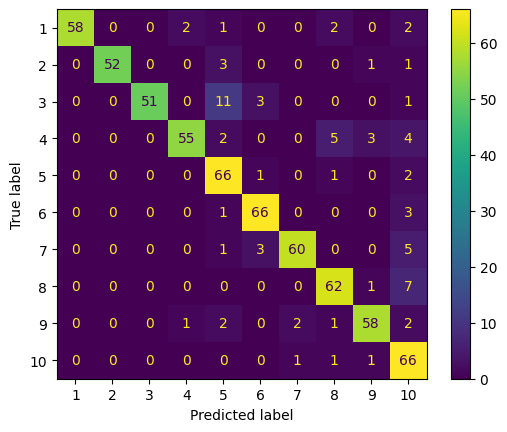

In [24]:
metrics, disp = test_svm(model, transp_xs.cpu(), y_tests[1].cpu())
disp.plot()
print(metrics)

# Using barycenter distributions

Lets first compute the barycenter of the distribution

In [25]:
n_train = 0
for i in range(len(X_trains)):
    n_train += X_trains[i].shape[0]
n_train

758

In [26]:
a1, a2, a3, a4 = ot.unif(len(X_trains[0])), ot.unif(len(X_trains[1])), ot.unif(len(X_trains[2])), ot.unif(len(X_trains[3]))
weights = [torch.tensor(a1, dtype=torch.float32, device=device), torch.tensor(a2, dtype=torch.float32, device=device), torch.tensor(a3, dtype=torch.float32, device=device), torch.tensor(a4, dtype=torch.float32, device=device)]

In [27]:
# Equal number of classes in train
# Barycenter number of points can be lower i think

In [28]:
reg = 1e-1  # Entropic Regularization
numItermax = 10  # Maximum number of iterations for the Barycenter algorithm
numInnerItermax = 3000  # Maximum number of sinkhorn iterations

recompute = False

if not recompute and os.path.exists('barycenter_simple.npy'):
    barycenter = np.load('barycenter_simple.npy')
    barycenter = torch.tensor(barycenter, dtype=torch.float32, device=device)
    print('Barycenter loaded')
else:
    barycenter = free_support_sinkhorn_barycenter(
        measures_locations=X_trains,
        measures_weights=weights,
        reg=1e-1,
        numItermax=10,
        numInnerItermax=3000,
        verbose=True,
        X_init=torch.rand(size=(n_train, 4096), device=device),
        b=torch.ones(size=(n_train,), device=device) / n_train,
        method='sinkhorn_log',
        stopThr=0.0001
    )
    np.save('barycenter_simple.npy', barycenter.cpu())

Barycenter loaded


In [29]:
barycenter.shape, X_trains[0].shape

(torch.Size([758, 4096]), torch.Size([88, 4096]))

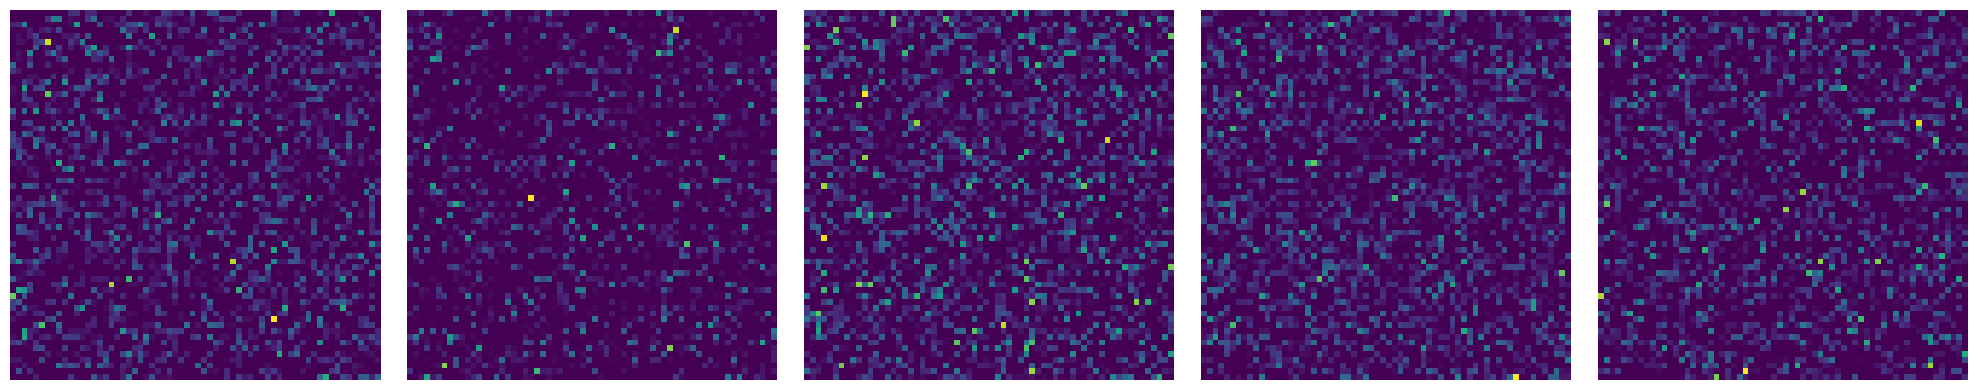

In [30]:
visualize_barycenter_diracs(barycenter.cpu(), num_images=5, random_seed=42)
plt.show()

In [31]:
y_bari = torch.concatenate(y_trains).cpu()
barysvm = train_svm(barycenter.cpu(), y_bari.cpu(), kernel='rbf', C=2.0)
model.fit_status_ == 0

[LibSVM].*
optimization finished, #iter = 278
obj = -142.877943, rho = -0.241332
nSV = 155, nBSV = 40
.*
optimization finished, #iter = 267
obj = -143.104942, rho = -0.401273
nSV = 156, nBSV = 41
.*
optimization finished, #iter = 273
obj = -155.627392, rho = -0.369185
nSV = 168, nBSV = 47
.*
optimization finished, #iter = 255
obj = -140.064416, rho = -0.365680
nSV = 151, nBSV = 36
.*
optimization finished, #iter = 280
obj = -157.856319, rho = 0.022689
nSV = 168, nBSV = 40
.*
optimization finished, #iter = 260
obj = -160.413641, rho = 0.146513
nSV = 172, nBSV = 92
.*
optimization finished, #iter = 245
obj = -147.986596, rho = -0.239992
nSV = 155, nBSV = 43
.*
optimization finished, #iter = 250
obj = -140.155871, rho = -0.067759
nSV = 149, nBSV = 36
.*
optimization finished, #iter = 270
obj = -147.213030, rho = -0.576254
nSV = 158, nBSV = 37
.*
optimization finished, #iter = 259
obj = -127.182148, rho = -0.143653
nSV = 140, nBSV = 45
.*
optimization finished, #iter = 275
obj = -139.97811

True

/Users/balazsmorvay/anaconda3/envs/fmri_classifier/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:748: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn("Sinkhorn did not converge. You might want to "


{'accuracy': 0.9090909090909091, 'recall': array([0.77777778, 0.83333333, 1.        , 1.        , 1.        ,
       0.88888889, 0.84615385, 0.88888889, 1.        , 0.88888889]), 'precision': array([1.        , 0.83333333, 1.        , 1.        , 0.8       ,
       0.88888889, 1.        , 0.88888889, 1.        , 0.72727273]), 'fscore': array([0.875     , 0.83333333, 1.        , 1.        , 0.88888889,
       0.88888889, 0.91666667, 0.88888889, 1.        , 0.8       ])}


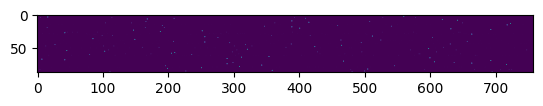

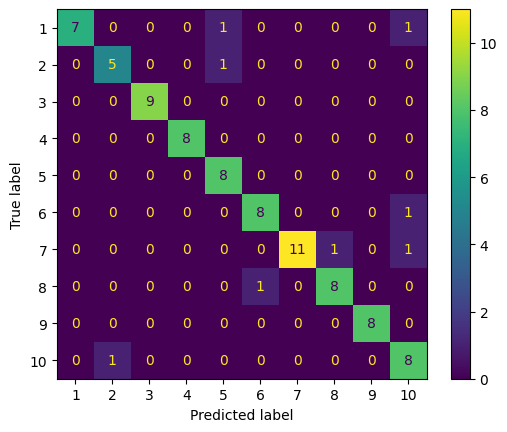

In [32]:
xs = X_trains[0]
xt = barycenter
ys = y_trains[0]
yt = y_bari.to(device)
M = dist_classreg(xs, xt, ys, yt, device=device)

a = torch.tensor([1.0 / xs.shape[0]] * xs.shape[0], dtype=torch.float32, device=device)
b = torch.tensor([1.0 / xt.shape[0]] * xt.shape[0], dtype=torch.float32, device=device)

P = ot.sinkhorn(a=a, b=b, reg=2e-1, M=M, method='sinkhorn_log')

plt.imshow(P.cpu())

transp_xs = barycentric_mapping(xs, xt, X_trains[0], P)

metrics, disp = test_svm(barysvm, transp_xs.cpu(), y_trains[0].cpu())
disp.plot()
print(metrics)

/Users/balazsmorvay/anaconda3/envs/fmri_classifier/lib/python3.11/site-packages/ot/backend.py:2214: UserWarning: The operator 'aten::_linalg_solve_ex.result' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:13.)
  return torch.linalg.solve(a, b)


It.  |Loss        |Delta loss
--------------------------------
    0|8.636546e+04|0.000000e+00
    1|8.636538e+04|-9.950447e-07
    2|8.636529e+04|-9.950458e-07
    3|8.636521e+04|-9.045880e-07
    4|8.636512e+04|-1.085506e-06
    5|8.636504e+04|-9.045897e-07
    6|8.636497e+04|-8.141315e-07
    7|8.636489e+04|-9.045913e-07
    8|8.636480e+04|-1.085511e-06
    9|8.636472e+04|-9.045931e-07
   10|8.636463e+04|-9.950534e-07
   11|8.636455e+04|-9.045948e-07
   12|8.636447e+04|-9.950552e-07
   13|8.636438e+04|-9.950562e-07
   14|8.636430e+04|-9.045975e-07
   15|8.636423e+04|-9.045983e-07
   16|8.636414e+04|-9.950589e-07
   17|8.636406e+04|-9.046000e-07
   18|8.636398e+04|-9.950609e-07
   19|8.636391e+04|-8.141415e-07
It.  |Loss        |Delta loss
--------------------------------
   20|8.636383e+04|-9.046024e-07
   21|8.636374e+04|-9.950636e-07
   22|8.636366e+04|-9.046042e-07
   23|8.636358e+04|-9.950654e-07
   24|8.636349e+04|-9.950664e-07
   25|8.636341e+04|-9.046068e-07
   26|8.636334e+0

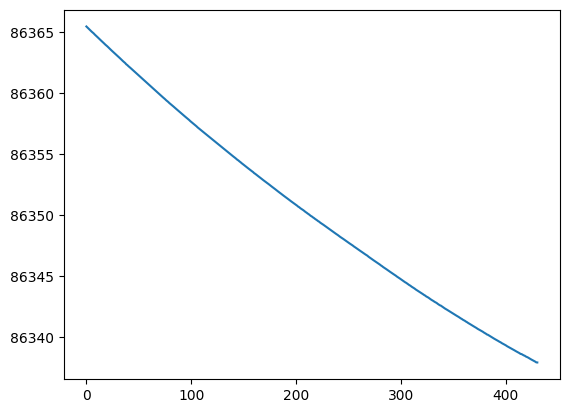

In [33]:
import ot.mapping

mapping_transport = MappingTransport(mu=1e-2, eta=1e-3, bias=True, max_iter=100000, max_inner_iter=1e15, log=True, verbose=True, tol=1e-7, kernel='gaussian', sigma=0.1)
mapping_transport.fit(Xs=X_trains[0], ys=y_trains[0].cpu(), Xt=barycenter, yt=y_bari.cpu())
transported_xs = mapping_transport.transform(Xs=X_trains[0])

plt.plot([l.cpu() for l in mapping_transport.log_["loss"]])
plt.show()

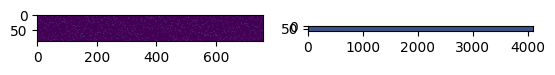

In [34]:
plt.subplot(1, 2, 1)
plt.imshow(mapping_transport.coupling_.cpu())
plt.subplot(1, 2, 2)
plt.imshow(mapping_transport.mapping_.cpu())
plt.show()

{'accuracy': 0.7613636363636364, 'recall': array([0.66666667, 1.        , 0.88888889, 1.        , 1.        ,
       0.44444444, 0.38461538, 0.77777778, 0.75      , 1.        ]), 'precision': array([1.        , 1.        , 0.66666667, 0.5       , 0.88888889,
       1.        , 1.        , 1.        , 1.        , 0.52941176]), 'fscore': array([0.8       , 1.        , 0.76190476, 0.66666667, 0.94117647,
       0.61538462, 0.55555556, 0.875     , 0.85714286, 0.69230769])}


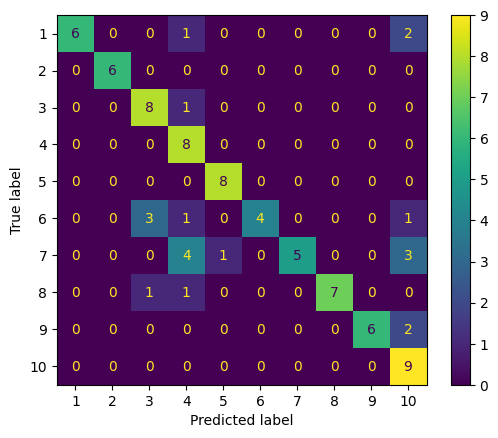

In [35]:
metrics, disp = test_svm(barysvm, transported_xs.cpu(), y_trains[0].cpu())
disp.plot()
print(metrics)

Gaussian mapping
{'accuracy': 0.10144927536231885, 'recall': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]), 'precision': array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.10144928]), 'fscore': array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.18421053])}


/Users/balazsmorvay/anaconda3/envs/fmri_classifier/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


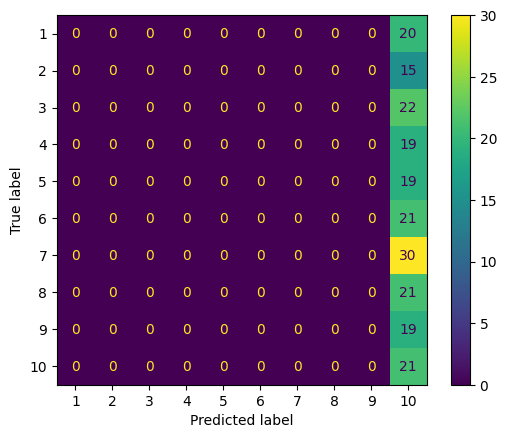

In [36]:
transformed_test = mapping_transport.transform(Xs=X_tests[0])
metrics, disp = test_svm(barysvm, transformed_test.cpu(), y_tests[0].cpu())
disp.plot()
print(metrics)


In [37]:
# Source 1 to bary
xs = torch.tensor([1.0 / xs.shape[0]] * xs.shape[0], dtype=torch.float32, device=device)
b = torch.tensor([1.0 / xt.shape[0]] * xt.shape[0], dtype=torch.float32, device=device)
G, L, loss = compute_joint_OT_mapping(xs=X_trains[0],
                                      xt=barycenter,
                                      ys=y_trains[0].cpu(),
                                      yt=y_bari.cpu(),
                                      method='gaussian',
                                      mu=1e-3,
                                      eta=1e-2,
                                      numItermax=30,
                                      numInnerItermax=int(1e8),
                                      stopThr=1e-8,
                                      stopInnerThr=1e-8,
                                      bias=False,
                                      class_reg=True)

G.shape, L.shape

It.  |Loss        |Delta loss
--------------------------------
    0|2.789366e+04|0.000000e+00
    1|2.775714e+04|-4.894285e-03
    2|2.762515e+04|-4.754970e-03
    3|2.749568e+04|-4.686696e-03
    4|2.736897e+04|-4.608323e-03
    5|2.724479e+04|-4.537528e-03
    6|2.712320e+04|-4.462938e-03
    7|2.700447e+04|-4.377307e-03
    8|2.688793e+04|-4.315692e-03
    9|2.677395e+04|-4.238950e-03
   10|2.666229e+04|-4.170332e-03
   11|2.655264e+04|-4.112491e-03
   12|2.644562e+04|-4.030760e-03
   13|2.634057e+04|-3.972258e-03
   14|2.623766e+04|-3.906685e-03
   15|2.613713e+04|-3.831711e-03
   16|2.603849e+04|-3.774040e-03
   17|2.594181e+04|-3.712954e-03
   18|2.584687e+04|-3.659709e-03
   19|2.575395e+04|-3.594790e-03
It.  |Loss        |Delta loss
--------------------------------
   20|2.566282e+04|-3.538443e-03
   21|2.557353e+04|-3.479468e-03
   22|2.548602e+04|-3.421812e-03
   23|2.540025e+04|-3.365586e-03
   24|2.531624e+04|-3.307208e-03
   25|2.523414e+04|-3.243270e-03
   26|2.515334e+0

(torch.Size([88, 758]), torch.Size([88, 4096]))

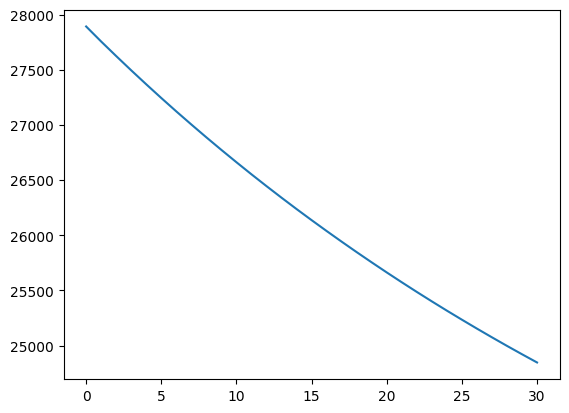

In [38]:
l = torch.tensor(loss['loss'], device = 'cpu')

plt.plot(l)

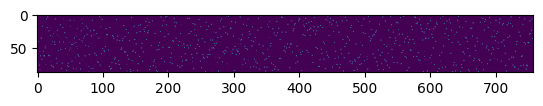

In [39]:
plt.imshow(G.cpu())

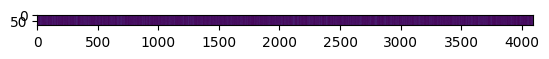

In [40]:
plt.imshow(L.cpu())

In [41]:
barysvm = train_svm(barycenter.cpu(), y_bari.cpu(), kernel='rbf', C=2.0)
model.fit_status_ == 0

[LibSVM].*
optimization finished, #iter = 278
obj = -142.877943, rho = -0.241332
nSV = 155, nBSV = 40
.*
optimization finished, #iter = 267
obj = -143.104942, rho = -0.401273
nSV = 156, nBSV = 41
.*
optimization finished, #iter = 273
obj = -155.627392, rho = -0.369185
nSV = 168, nBSV = 47
.*
optimization finished, #iter = 255
obj = -140.064416, rho = -0.365680
nSV = 151, nBSV = 36
.*
optimization finished, #iter = 280
obj = -157.856319, rho = 0.022689
nSV = 168, nBSV = 40
.*
optimization finished, #iter = 260
obj = -160.413641, rho = 0.146513
nSV = 172, nBSV = 92
.*
optimization finished, #iter = 245
obj = -147.986596, rho = -0.239992
nSV = 155, nBSV = 43
.*
optimization finished, #iter = 250
obj = -140.155871, rho = -0.067759
nSV = 149, nBSV = 36
.*
optimization finished, #iter = 270
obj = -147.213030, rho = -0.576254
nSV = 158, nBSV = 37
.*
optimization finished, #iter = 259
obj = -127.182148, rho = -0.143653
nSV = 140, nBSV = 45
.*
optimization finished, #iter = 275
obj = -139.97811

True

{'accuracy': 0.9327176781002638, 'recall': array([0.90588235, 0.97142857, 0.94366197, 0.90361446, 0.97014925,
       0.92857143, 0.88764045, 0.94366197, 0.96875   , 0.93243243]), 'precision': array([0.97468354, 0.91891892, 0.97101449, 0.91463415, 0.90277778,
       0.91764706, 0.94047619, 0.93055556, 0.93939394, 0.92      ]), 'fscore': array([0.93902439, 0.94444444, 0.95714286, 0.90909091, 0.9352518 ,
       0.92307692, 0.9132948 , 0.93706294, 0.95384615, 0.9261745 ])}


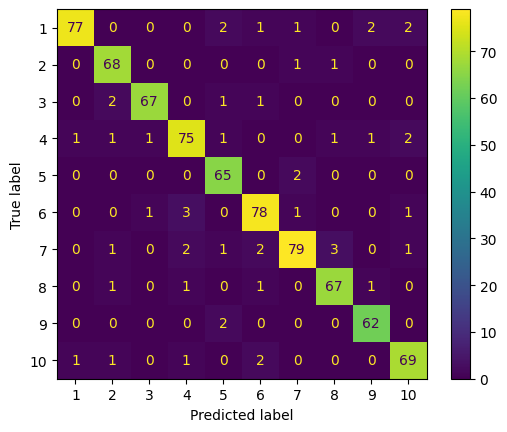

In [42]:
metrics, disp = test_svm(barysvm, barycenter.cpu(), y_bari.cpu())
disp.plot()
print(metrics)

In [43]:
mapped_source = barycentric_mapping(xs=X_trains[0],
                                    xt=barycenter,
                                    xnew=X_trains[0],
                                    coupling=G)
import ot.mapping
kernel = ot.mapping.kernel(X_trains[0], X_trains[0], method='gaussian', sigma=1e-3)
transported_source = np.dot(kernel.cpu(), L.cpu())

In [44]:
transported_source.shape

(88, 4096)

{'accuracy': 0.19318181818181818, 'recall': array([0.        , 0.16666667, 0.55555556, 0.375     , 0.        ,
       0.        , 0.15384615, 0.        , 0.        , 0.66666667]), 'precision': array([0.        , 0.5       , 0.5       , 0.23076923, 0.        ,
       0.        , 0.66666667, 0.        , 0.        , 0.16216216]), 'fscore': array([0.        , 0.25      , 0.52631579, 0.28571429, 0.        ,
       0.        , 0.25      , 0.        , 0.        , 0.26086957])}


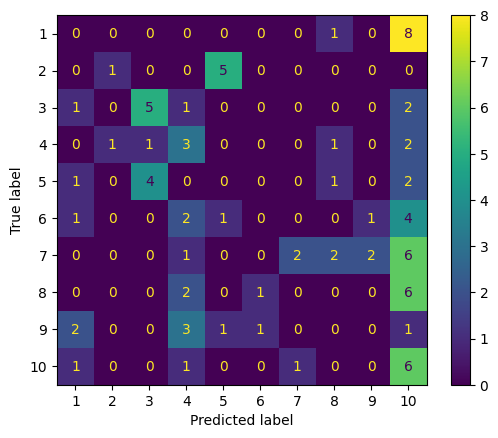

In [45]:
metrics, disp = test_svm(barysvm, transported_source, y_trains[0].cpu())
disp.plot()
print(metrics)

In [46]:
xs = X_trains[0].to(device)
xt = barycenter.to(device)
ys = y_trains[0].to(device)
yt = y_bari.to(device)
M = dist_classreg(xs, xt, ys, yt, device=device)

a = torch.tensor([1.0 / xs.shape[0]] * xs.shape[0], dtype=torch.float32, device=device)
b = torch.tensor([1.0 / xt.shape[0]] * xt.shape[0], dtype=torch.float32, device=device)

P = ot.sinkhorn(a=a, b=b, reg=5e-1, M=M, method='sinkhorn_log')

/Users/balazsmorvay/anaconda3/envs/fmri_classifier/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:748: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn("Sinkhorn did not converge. You might want to "


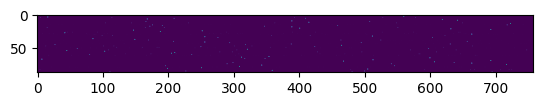

In [47]:
plt.imshow(P.cpu())

In [48]:
mapped_source_sinkhorn = barycentric_mapping(xs=X_trains[0],
                                    xt=barycenter,
                                    xnew=X_trains[0],
                                    coupling=P)
mapped_test_sinkhorn = barycentric_mapping(xs=X_trains[0],
                                    xt=barycenter,
                                    xnew=X_tests[0],
                                    coupling=P)

In [49]:
X_tests[0].shape, y_tests[0].shape, mapped_test_sinkhorn.shape

(torch.Size([207, 4096]), torch.Size([207]), torch.Size([207, 4096]))

{'accuracy': 0.8977272727272727, 'recall': array([0.77777778, 1.        , 1.        , 0.875     , 1.        ,
       0.88888889, 0.76923077, 0.88888889, 1.        , 0.88888889]), 'precision': array([0.875     , 0.85714286, 1.        , 1.        , 0.8       ,
       0.88888889, 1.        , 0.88888889, 1.        , 0.72727273]), 'fscore': array([0.82352941, 0.92307692, 1.        , 0.93333333, 0.88888889,
       0.88888889, 0.86956522, 0.88888889, 1.        , 0.8       ])}


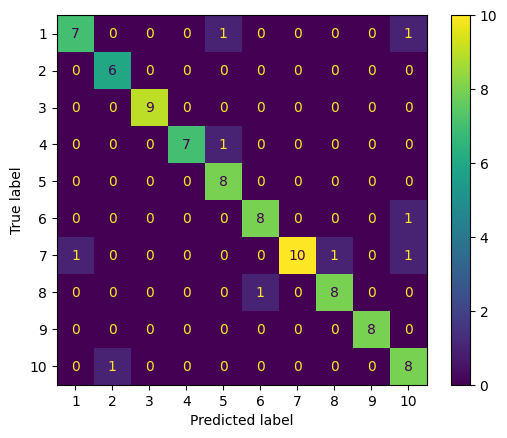

In [50]:
metrics, disp = test_svm(barysvm, mapped_source_sinkhorn.cpu(), y_trains[0].cpu())
disp.plot()
print(metrics)